# Player Visualisations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mplsoccer import Pitch
from ipywidgets import Dropdown, interact
from IPython.display import display, HTML
import os

from data_reading import get_events, get_player_positions
from shared_visuals import draw_pitch, get_short_name, get_player_nickname
# Global variables
BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
PITCH_X, PITCH_Y = 120, 80



## Read Data

In [2]:
events_df = get_events(
    target={
    "Competition":"FIFA World Cup",
    "Season": "2022"
    }
    )



c:\Users\luker\OneDrive - University of Bristol\Other\Extra Projects\src\General_visualisations\data_reading.py:273: DtypeWarning: Columns (0: clearance.aerial_won, 1: pass.deflected, 2: block.deflection, 3: foul_committed.advantage, 4: foul_won.advantage, 5: foul_committed.card.name, 6: pass.inswinging, 7: pass.miscommunication, 8: pass.goal_assist, 9: pass.through_ball, 10: shot.one_on_one, 11: dribble.nutmeg, 12: dribble.overrun, 13: 50_50.outcome.name, 14: injury_stoppage.in_chain, 15: dribble.no_touch, 16: clearance.other, 17: pass.outswinging, 18: shot.aerial_won, 19: shot.open_goal, 20: miscontrol.aerial_won, 21: foul_committed.type.name, 22: shot.deflected, 23: pass.cut_back, 24: foul_committed.offensive, 25: block.offensive, 26: shot.saved_to_post, 27: goalkeeper.shot_saved_to_post, 28: foul_committed.penalty, 29: foul_won.penalty, 30: ball_recovery.offensive, 31: pass.straight, 32: pass.no_touch, 33: shot.redirect, 34: goalkeeper.punched_out, 35: bad_behaviour.card.name, 36: 

Event data read from file
Events loaded: (234637, 153)


## Main

In [3]:
def get_player_data(event_data, match_id=None, player_name=None):
    """Return all events for a specific player, optionally filtered to one match."""
    event_data = event_data.copy()

    # Filter for the specific match if match_id is provided
    if match_id is not None:
        event_data = event_data.loc[event_data["match_id"].eq(match_id)].copy()

    # Group events by player_name, then filter for the specific player
    # player_name = event_data["player_name"].dropna().astype(str).unique()[0]
    player_events = event_data.loc[event_data["player_name"].eq(player_name)].copy()
    print("Shape:", player_events.shape)
    return player_events

def get_team_names(event_data):
    """Return a list of unique team names in the event data."""
    return sorted(event_data["team_name"].dropna().astype(str).unique().tolist())

def get_team_players(event_data, team_name):
    """Return a list of unique player names for a specific team that have played in any games."""
    return sorted(event_data.loc[event_data["team_name"] == team_name, "player_name"].dropna().unique().tolist())

def get_matches_by_team(event_data, team_name):
    """Return a list of unique match IDs for a specific team."""
    return sorted(event_data.loc[event_data["team_name"] == team_name, "match_id"].dropna().unique().tolist())

def get_matches_by_player(event_data, player_name):
    """Return a list of unique match IDs for a specific player."""
    return sorted(event_data.loc[event_data["player_name"] == player_name, "match_id"].dropna().unique().tolist())

def get_player_team_name(event_data, player_name):
    """Return the team name for a specific player."""
    team_names = event_data.loc[event_data["player_name"] == player_name, "team_name"].dropna().astype(str)
    if not team_names.empty:
        return team_names.mode().iloc[0]
    else:
        return None
def get_player_names(event_data):
    """Return a list of unique player names in the event data."""
    return sorted(event_data["player_name"].dropna().astype(str).unique().tolist())

In [4]:
def update_player_dropdown(*args):
    """Update the player dropdown and show the players as a list/table."""
    selected_team = team_dropdown.value
    player_names = get_team_players(events_df, selected_team)

    player_dropdown.options = player_names
    if player_names:
        player_dropdown.value = player_names[0]


def player_display(player_name):
    """Show the player event data in a compact table."""
    player_data = events_df[events_df['player_name'] == player_name]
    display(HTML(player_data.to_html(index=False)))


# Create dropdown choice for available teams
team_names = get_team_names(events_df)
team_dropdown = Dropdown(
    options=team_names,
    description='Select Team:',
    value=team_names[0]
)

player_dropdown = Dropdown(
    options=get_team_players(events_df, team_names[0]),
    description='Select Player:'
)

team_dropdown.observe(update_player_dropdown, names='value')

display(team_dropdown)
display(player_dropdown)

Dropdown(description='Select Team:', options=('Argentina', 'Australia', 'Belgium', 'Brazil', 'Cameroon', 'Cana…

Dropdown(description='Select Player:', options=('Alejandro Darío Gómez', 'Alexis Mac Allister', 'Cristian Gabr…

### Positions


In [5]:
POSITION_MAP = {
        "Goalkeeper": (5, 40),

        # Defence
        "Right Back": (20, 68),
        "Right Wing Back": (26, 72),
        "Right Center Back": (20, 55),
        "Center Back": (20, 40),
        "Left Center Back": (20, 25),
        "Left Back": (20, 12),
        "Left Wing Back": (26, 8),

        # Defensive midfield
        "Right Defensive Midfield": (42, 52),
        "Center Defensive Midfield": (42, 40),
        "Left Defensive Midfield": (42, 28),

        # Central midfield
        "Right Center Midfield": (58, 60),
        "Center Midfield": (58, 40),
        "Left Center Midfield": (58, 20),

        # Wide midfield
        "Right Midfield": (65, 72),
        "Left Midfield": (65, 8),

        # Attacking midfield
        "Center Attacking Midfield": (72, 40),
        "Left Attacking Midfield": (72, 20),
        "Right Attacking Midfield": (72, 60),

        # Attack
        "Right Wing": (88, 72),
        "Left Wing": (88, 8),

        "Right Center Forward": (92, 60),
        "Left Center Forward": (92, 20),

        "Secondary Striker": (88, 40),
        "Center Forward": (96, 40),
        "Striker": (96, 40),
}

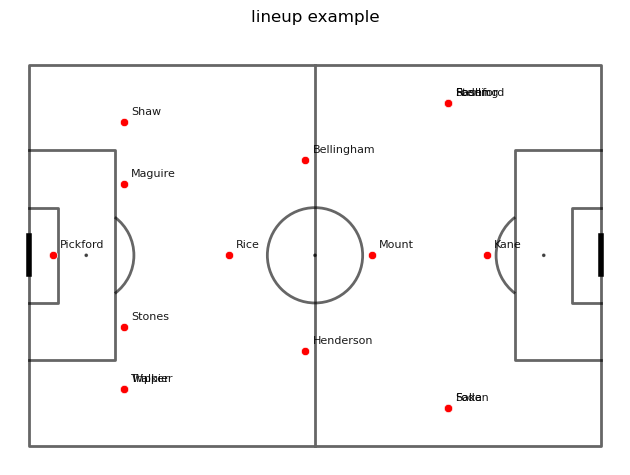

In [6]:
def display_lineup(events_df, season_positions, teamname, title="lineup example", use_nicknames=False):
    '''Visualise the average positions of players on a pitch using mplsoccer.'''
    # Map positions to coordinates
    season_player_coordinates = {}
    for player, pos in season_positions.items():
        x, y = POSITION_MAP[pos]
        season_player_coordinates[player] = [x,y]
    coords = np.array(list(season_player_coordinates.values()))


    # Display on mplsoccer Pitch
    fig, ax = plt.subplots()
    draw_pitch(ax, draw_half=False)
    sns.scatterplot(
        x = coords[:,0],
        y = coords[:,1],
        legend=False,
        c='red',
        )
    fig.suptitle(title, fontsize=12)

    # Get player nickname mappings for the team
    if use_nicknames:
        name_mappings = get_player_nickname(events_df, teamname)
    else:
        name_mappings = {}

    for p in season_player_coordinates.keys():
        # Use the mapping if available, otherwise use the original name
        name = name_mappings.get(p, get_short_name(p))  
        # Catch case where name is Nan and use full name instead
        if pd.isna(name):
            name = p
        ax.annotate(
            name,
            POSITION_MAP[season_positions[p]],
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            alpha=0.9,

            )
    fig.tight_layout()    
    plt.show()

# Get average positions for players over the full competition (EXAMPLE: England)
season_positions = get_player_positions(events_df, "England", season_level=True)
display_lineup(events_df, season_positions, "England", title="lineup example")

### Nickname Mapping

In [7]:
# Get mappings for chosen team
teamname = "Brazil"
team_events_df = events_df[events_df["team_name"] == teamname].copy()
spain_mapping_dict = get_player_nickname(events_df, teamname, redo=False)

# Add to df
team_events_df["player_nickname"] = team_events_df["player_name"].map(spain_mapping_dict)
print(team_events_df[["player_name", "player_nickname"]].drop_duplicates().head(10))


Loading existing mapping from Data_processing\name_mappings\brazil_mapping.csv
                                   player_name  player_nickname
83163                                      NaN              NaN
83180                       Marcos Aoás Corrêa       Marquinhos
83185  Vinícius José Paixão de Oliveira Júnior  Vinícius Júnior
83191                 Carlos Henrique Casimiro         Casemiro
83192           Lucas Tolentino Coelho de Lima    Lucas Paquetá
83195                   Alex Sandro Lobo Silva      Alex Sandro
83202                 Thiago Emiliano da Silva     Thiago Silva
83208                     Éder Gabriel Militão     Éder Militão
83211                    Alisson Ramsés Becker   Alisson Becker
83231               Frederico Rodrigues Santos             Fred


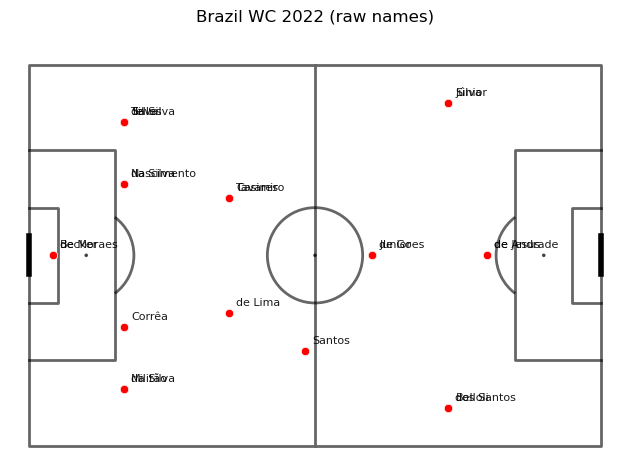

Loading existing mapping from Data_processing\name_mappings\brazil_mapping.csv


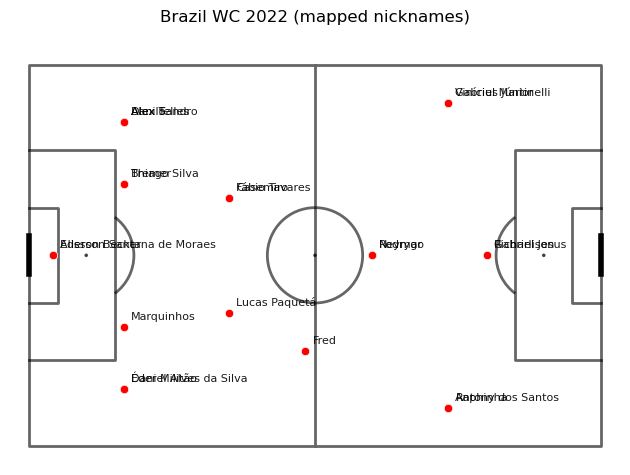

In [8]:
chosen_team_positions = get_player_positions(events_df, teamname, season_level=True)
display_lineup(events_df, chosen_team_positions, teamname, f"{teamname} WC 2022 (raw names)", use_nicknames=False)
display_lineup(events_df, chosen_team_positions, teamname, f"{teamname} WC 2022 (mapped nicknames)", use_nicknames=True)

### Dimensionality Reduction


In [9]:
# Identify goalkeeper names before building the shared PCA.
goalkeeper_names = set(
    events_df.loc[
        events_df["position.name"].eq("Goalkeeper"),
        "player_name",
    ]
    .dropna()
    .astype(str)
    .unique()
)

print(f"Goalkeepers found: {len(goalkeeper_names)}")
print(sorted(goalkeeper_names))

Goalkeepers found: 41
['Alireza Safar Beiranvand', 'Alisson Ramsés Becker', 'Andries Noppert', 'André Onana', 'Aymen Dahmen', 'Damián Emiliano Martínez', 'Daniel Ward', 'Devis Rogers Epassy Mboka', 'Diogo Meireles Costa', 'Dominik Livaković', 'Ederson Santana de Moraes', 'Edouard Mendy', 'Francisco Guillermo Ochoa Magaña', 'Gregor Kobel', 'Hernán Ismael Galíndez', 'Hugo Lloris', 'Jordan Pickford', 'Kasper Schmeichel', 'Keylor Navas Gamboa', 'Lawrence Ati-Zigi', 'Manuel Neuer', 'Mathew Ryan', 'Matthew Charles Turner', 'Meshaal Aissa Barsham', 'Milan Borjan', 'Mohammed Khalil Al Owais', 'Munir Mohand Mohamedi', 'Saad Abdullah Al Sheeb', 'Sergio Rochet Álvarez', 'Seung-Gyu Kim', 'Seyed Hossein Hosseini', 'Shūichi Gonda', 'Steve Mandanda', 'Thibaut Courtois', 'Unai Simón Mendibil', 'Vanja Milinković Savić', 'Wayne Hennessey', 'Weverton Pereira da Silva', 'Wojciech Szczęsny', 'Yann Sommer', 'Yassine Bounou']


#### Initial Scatter

C:\Users\luker\AppData\Local\Temp\ipykernel_28264\487761792.py:40: DtypeWarning: Columns (0: pass.switch, 1: pass.cross, 2: clearance.aerial_won, 3: clearance.head, 4: clearance.body_part.name, 5: off_camera, 6: shot.end_location, 7: shot.key_pass_id, 8: shot.technique.name, 9: shot.body_part.name, 10: shot.type.name, 11: shot.outcome.name, 12: shot.first_time, 13: shot.freeze_frame, 14: goalkeeper.end_location, 15: goalkeeper.position.name, 16: goalkeeper.type.name, 17: clearance.right_foot, 18: pass.deflected, 19: block.deflection, 20: goalkeeper.technique.name, 21: goalkeeper.outcome.name, 22: pass.aerial_won, 23: foul_committed.advantage, 24: foul_won.advantage, 25: foul_committed.card.name, 26: pass.inswinging, 27: pass.technique.name, 28: pass.miscommunication, 29: clearance.left_foot, 30: pass.goal_assist, 31: pass.through_ball, 32: shot.one_on_one, 33: dribble.nutmeg, 34: dribble.overrun, 35: 50_50.outcome.name, 36: injury_stoppage.in_chain, 37: dribble.no_touch, 38: clearance.

Loaded player_events.csv
Built player event mapping for 640 outfield players
Numeric columns for aggregation: ['possession', 'type.id', 'possession_team.id', 'play_pattern.id', 'team.id', 'tactics.formation', 'tactics.lineup', 'player.id', 'pass.recipient.id', 'pass.length', 'pass.angle', 'pass.height.id', 'pass.body_part.id', 'pass.type.id', 'pass.outcome.id', 'ball_receipt.outcome.id', 'duel.type.id', 'clearance.body_part.id', 'shot.statsbomb_xg', 'shot.technique.id', 'shot.body_part.id', 'shot.type.id', 'shot.outcome.id', 'goalkeeper.position.id', 'goalkeeper.type.id', 'goalkeeper.technique.id', 'goalkeeper.outcome.id', 'duel.outcome.id', 'dribble.outcome.id', 'foul_committed.card.id', 'pass.technique.id', 'interception.outcome.id', '50_50.outcome.id', 'substitution.outcome.id', 'substitution.replacement.id', 'goalkeeper.body_part.id', 'foul_committed.type.id', 'bad_behaviour.card.id', 'half_start.late_video_start']
Loading existing mapping from Data_processing\name_mappings\argenti

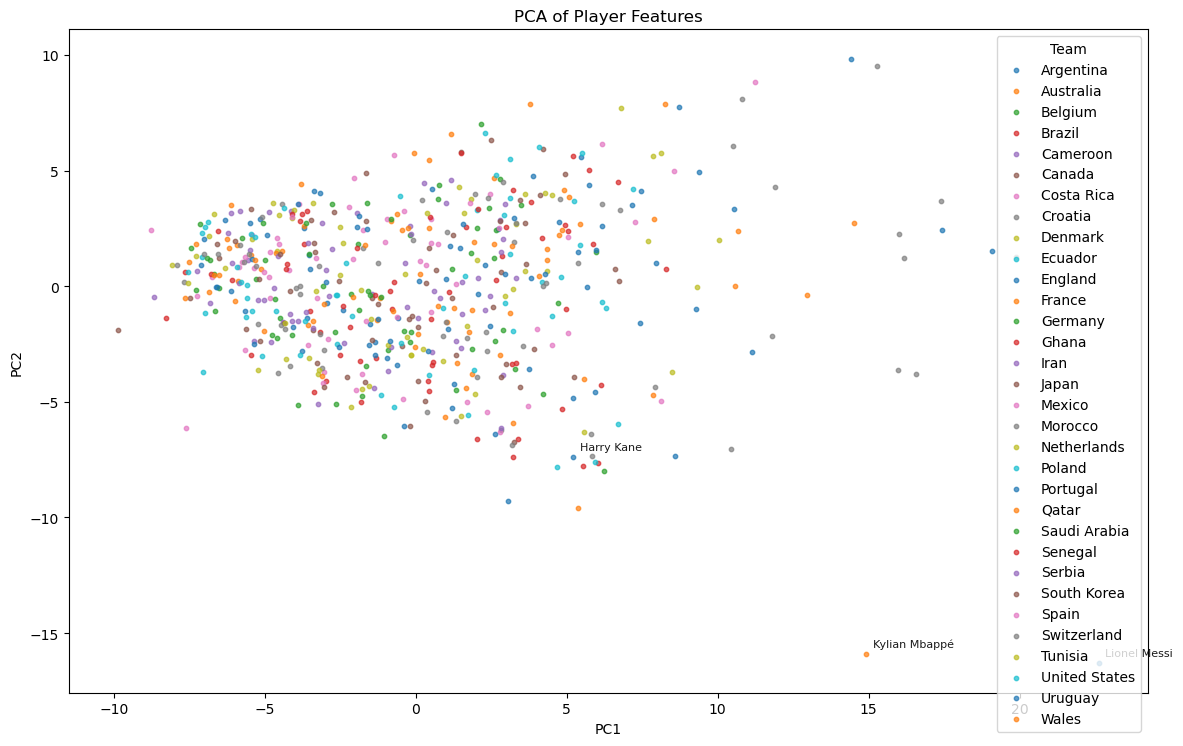

In [20]:
# Build a player-indexed event structure and a PCA-ready feature matrix

def build_player_event_data(event_data: pd.DataFrame):
    """Return a dict mapping each player to their events."""
    event_data = event_data.copy()
    if "player_name" not in event_data.columns:
        event_data["player_name"] = event_data.get(
            "player.name",
            pd.Series(np.nan, index=event_data.index),
        )

    event_data = event_data.dropna(subset=["player_name"])
    return {
        player_key: player_events.copy()
        for player_key, player_events in event_data.groupby("player_name", sort=True)
    }


def load_player_event_data(
    source_df: pd.DataFrame,
    cache_path: str = "player_data.csv",
    exclude_players: set[str] | None = None,
):
    """Return a dict of player -> events, excluding goalkeepers if requested."""
    df_to_use = source_df
    if os.path.exists(cache_path):
        cached_df = pd.read_csv(cache_path)
        if isinstance(cached_df, pd.DataFrame) and "player_name" in cached_df.columns:
            df_to_use = cached_df

    if exclude_players is not None and "player_name" in df_to_use.columns:
        df_to_use = df_to_use.loc[
            ~df_to_use["player_name"].astype(str).isin({str(p) for p in exclude_players})
        ].copy()

    return build_player_event_data(df_to_use)


if os.path.exists("player_events.csv"):
    player_events_df = pd.read_csv("player_events.csv")
    print("Loaded player_events.csv")
else:
    player_events_df = events_df
    print("Using events_df directly")

# Exclude goalkeepers from the PCA, since the analysis is meant for outfield players only.
player_events_df = player_events_df.loc[
    ~player_events_df["player_name"].astype(str).isin({str(p) for p in goalkeeper_names})
].copy()

player_data = load_player_event_data(player_events_df, "player_data.csv", exclude_players=goalkeeper_names)
print(f"Built player event mapping for {len(player_data)} outfield players")

# Keep a separate one-row-per-player table for PCA features.
player_df = pd.DataFrame(index=sorted(player_data))
player_feature_matrix = player_df.copy()

player_team_lookup = {}
for player_name, player_events in player_data.items():
    team_names = player_events["team_name"].dropna().astype(str)
    if not team_names.empty:
        player_team_lookup[player_name] = team_names.mode().iat[0]
    else:
        player_team_lookup[player_name] = "Unknown"

player_feature_matrix["team_name"] = [
    player_team_lookup.get(player_name, "Unknown")
    for player_name in player_feature_matrix.index
]


# Drop unwanted columns from the events DataFrame to avoid including them in PCA
columns_to_drop = [
    "match_id",
    "x",
    "y",
    "index",
    "minute",
    "second",
    "duration",
    "period",
    "player_name",
    "Unnamed: 0",
    "position.id",
    
]

# Aggregate numeric features for each player
numeric_columns = player_events_df.select_dtypes(include="number").columns
numeric_columns = numeric_columns.drop(columns_to_drop, errors="ignore")
print(f"Numeric columns for aggregation: {numeric_columns.tolist()}")

player_feature_matrix = player_events_df.groupby("player_name").agg(
    **{
        f"{column}_mean": (column, "mean")
        for column in numeric_columns
    },
    **{
        f"{column}_sum": (column, "sum")
        for column in numeric_columns
    },
    matches_played=("match_id", "nunique"),
    team_name=("team_name", lambda values: values.mode().iat[0]),
)

# Add categorical features for each player
for column in ["event_type", "shot_outcome", "pass_outcome"]:
    if column in player_events_df.columns:
        counts = pd.crosstab(
            player_events_df["player_name"],
            player_events_df[column],
            normalize="index",
        ).add_prefix(f"{column}_share_")

        player_feature_matrix = player_feature_matrix.join(counts, how="left")

# Add counts for each event type seen in the competition
for event_type in sorted(player_events_df["event_type"].dropna().astype(str).unique()):
    player_feature_matrix[event_type] = [
        int((player_events.get("event_type", pd.Series([np.nan] * len(player_events))) == event_type).sum())
        for player_events in player_data.values()
    ]

player_feature_matrix = player_feature_matrix.fillna(0)

# Save the exact columns used to fit PCA before later analysis adds features.
pca_feature_names = player_feature_matrix.drop(columns=["team_name"]).columns.tolist()

# Scale features before dimensionality reduction
scaler = StandardScaler()
player_features_scaled = scaler.fit_transform(player_feature_matrix[pca_feature_names])

# Fit PCA on the player feature matrix
pca = PCA(n_components=2)
player_pca = pca.fit_transform(player_features_scaled)

player_pca_df = pd.DataFrame(
    player_pca,
    index=player_feature_matrix.index,
    columns=["PC1", "PC2"],
)
player_pca_df["team_name"] = player_feature_matrix["team_name"].values

team_names = sorted(player_pca_df["team_name"].dropna().astype(str).unique())
palette = sns.color_palette("tab10", n_colors=max(len(team_names), 1))
team_colours = dict(zip(team_names, palette))
teams_to_include = [
    "Japan", "France", "Argentina", "England",
    "Morocco", "Spain", "Brazil", "Germany",
    "Ecuador", "Iran", "Ghana", "Costa Rica",
    "Portugal", "Netherlands", "Belgium",
    "Croatia", "Switzerland", "Senegal",
]
teams_to_include = team_names
fig, ax = plt.subplots(figsize=(12, 8))
for team_name in team_names:
    if team_name in teams_to_include:
        team_points = player_pca_df[player_pca_df["team_name"] == team_name]
        ax.scatter(
            team_points["PC1"],
            team_points["PC2"],
            alpha=0.7,
            s=10,
            c=[team_colours[team_name]],
            label=team_name,
        )

players_to_label = ["Lionel Andrés Messi Cuccittini", "Harry Kane", "Kylian Mbappé Lottin", "Cristiano Ronaldo"]
players_to_label = [
    name for name in players_to_label
    if name in player_pca_df.index and name not in goalkeeper_names
]

for player_name in players_to_label:
    point = player_pca_df.loc[player_name]
    teamname = get_player_team_name(events_df, player_name)
    preferred_name = get_player_nickname(events_df, teamname, player_name)
    if preferred_name is not None and not pd.isna(preferred_name):
        player_name = preferred_name
    ax.annotate(
        player_name,
        (point["PC1"], point["PC2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.9,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of Player Features")
ax.legend(title="Team", loc="best")
plt.tight_layout()

#### Feature Importance

Features contributing most to PC1:


,PC1,PC1_abs
play_pattern.id_sum,0.183950,0.183950
Ball Receipt*,0.182084,0.182084
type.id_sum,0.181855,0.181855
possession_sum,0.181717,0.181717
Carry,0.175320,0.175320
pass.height.id_sum,0.175167,0.175167
Ball Recovery,0.172575,0.172575
Pass,0.171638,0.171638
pass.body_part.id_sum,0.169836,0.169836
matches_played,0.167036,0.167036


Features contributing most to PC2:


,PC2,PC2_abs
event_type_share_Pass,0.215033,0.215033
ball_receipt.outcome.id_sum,-0.197721,0.197721
shot.type.id_sum,-0.190045,0.190045
shot.body_part.id_sum,-0.189950,0.189950
shot.outcome.id_sum,-0.189899,0.189899
Shot,-0.189888,0.189888
shot.technique.id_sum,-0.189867,0.189867
event_type_share_Shot,-0.173828,0.173828
Miscontrol,-0.172805,0.172805
shot.statsbomb_xg_sum,-0.171981,0.171981


,weighted_importance
pass.height.id_sum,0.007225
play_pattern.id_sum,0.007195
Pass,0.007046
type.id_sum,0.007030
pass.length_sum,0.006973
possession_sum,0.006873
pass.body_part.id_sum,0.006870
Ball Receipt*,0.006794
Carry,0.006745
Ball Recovery,0.005888


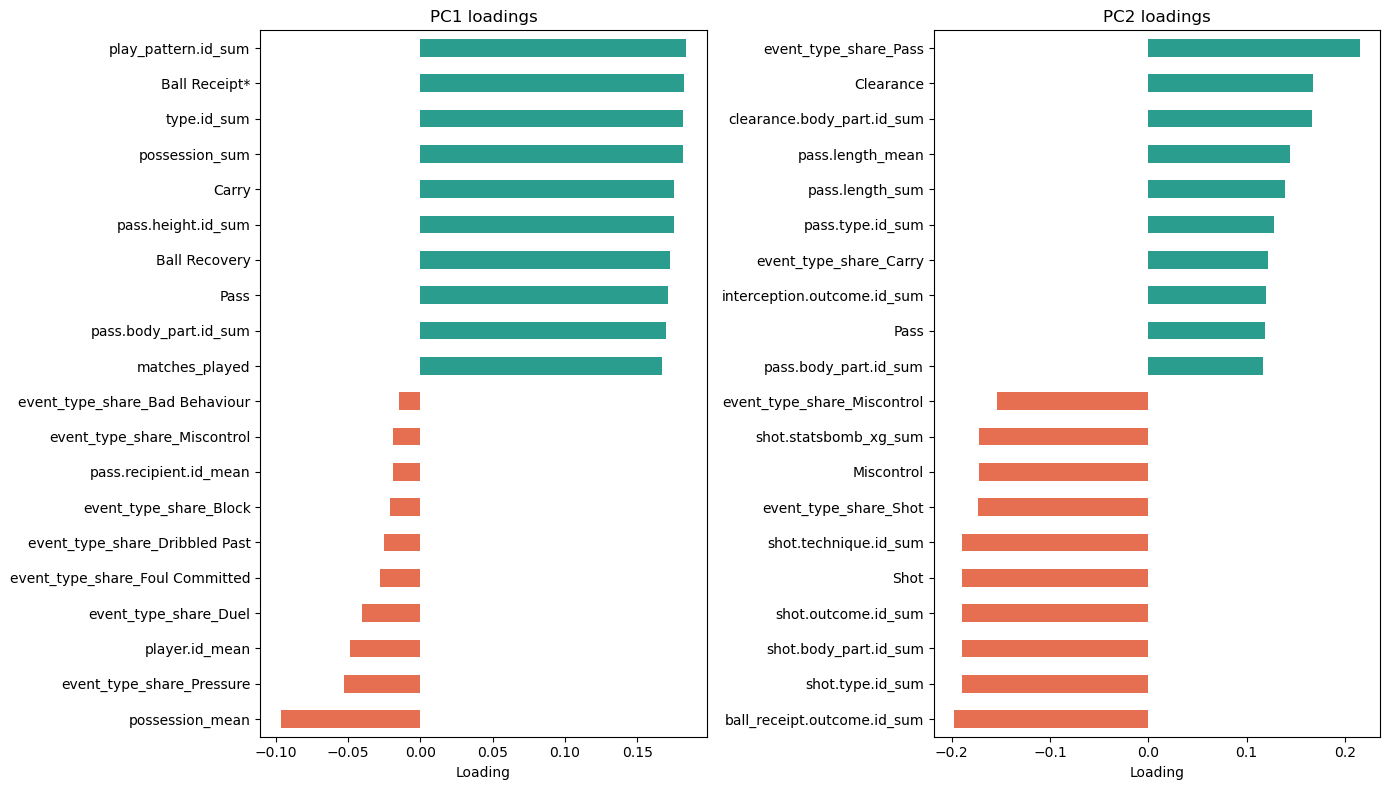

In [21]:
# PCA feature contributions
# The loadings show each feature's direction and strength in each component.
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_feature_names,
    columns=[f"PC{index + 1}" for index in range(pca.n_components_)],
)

pca_loadings["PC1_abs"] = pca_loadings["PC1"].abs()
pca_loadings["PC2_abs"] = pca_loadings["PC2"].abs()

print("Features contributing most to PC1:")
display(
    pca_loadings.sort_values("PC1_abs", ascending=False)
    [["PC1", "PC1_abs"]]
    .head(15)
)

print("Features contributing most to PC2:")
display(
    pca_loadings.sort_values("PC2_abs", ascending=False)
    [["PC2", "PC2_abs"]]
    .head(15)
)

# Overall contribution, weighted by the variance explained by each component.
weighted_importance = (
    pca_loadings[[f"PC{index + 1}" for index in range(pca.n_components_)]]
    .pow(2)
    .mul(pca.explained_variance_ratio_, axis=1)
    .sum(axis=1)
    .sort_values(ascending=False)
    .rename("weighted_importance")
)

display(weighted_importance.head(20).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for axis, component in zip(axes, ["PC1", "PC2"]):
    top_loadings = pca_loadings[component].sort_values().tail(10)
    bottom_loadings = pca_loadings[component].sort_values().head(10)
    plot_loadings = pd.concat([bottom_loadings, top_loadings])
    plot_loadings.plot.barh(ax=axis, color=np.where(plot_loadings >= 0, "#2a9d8f", "#e76f51"))
    axis.set_title(f"{component} loadings")
    axis.set_xlabel("Loading")

plt.tight_layout()

#### Positional

In [22]:
# Change colour of the points based on the player position
# Sort positions into groups
CBs = ["Right Center Back", "Center Back", "Left Center Back"]
FBs = ["Right Back", "Left Back", "Right Wing Back", "Left Wing Back"]
DMs = ["Right Defensive Midfield", "Center Defensive Midfield", "Left Defensive Midfield"]
CMs = ["Right Center Midfield", "Center Midfield", "Left Center Midfield"]
CAMs = ["Center Attacking Midfield"]
W = ["Right Wing", "Left Wing", "Right Midfield", "Left Midfield",
     "Right Attacking Midfield", "Left Attacking Midfield"
     ]
STs = ["Secondary Striker", "Center Forward", "Striker", "Right Center Forward", "Left Center Forward"]
GKs = ["Goalkeeper"]

# Place in dictionary for easy access
position_groups = {
    "CB": CBs,
    "FB": FBs,
    "DM": DMs,
    "CM": CMs,
    "CAM": CAMs,
    "W": W,
    "ST": STs,
    "GK": GKs
}
position_groups2 = {
    "GK": GKs,
    "DEF": CBs+FBs,
    "MID": DMs+CMs+CAMs,
    "WNG": W,
    "ATT": STs
}

# Assign colours to each position group using a color map
cmap = plt.get_cmap("Dark2")
position_colours = {
    group: cmap(index)
    for index, group in enumerate(position_groups)
}



# Get each player's modal starting position across every match in the competition
player_positions = {}
for team in get_team_names(events_df):
    team_events = events_df[events_df["team_name"] == team]
    player_positions.update(get_player_positions(team_events, team, season_level=True))

# Most frequently recorded StatsBomb position for each player
event_positions = (
    events_df.dropna(subset=["player_name", "position.name"])
    .groupby("player_name")["position.name"]
    .agg(lambda positions: positions.mode().iat[0])
    .to_dict()
)

# Use event-derived positions
player_positions = {
    **event_positions,
    # **player_positions,  # starting-lineup positions
}

player_pca_df["position"] = player_pca_df.index.map(player_positions)


# Map both the raw position and its group onto the PCA dataframe by player name
position_to_group = {
    position: group
    for group, positions in position_groups.items()
    for position in positions
}
player_pca_df["position"] = player_pca_df.index.map(player_positions)
player_pca_df["position_group"] = (
    player_pca_df["position"]
    .map(position_to_group)
    .fillna("Unknown position")
)


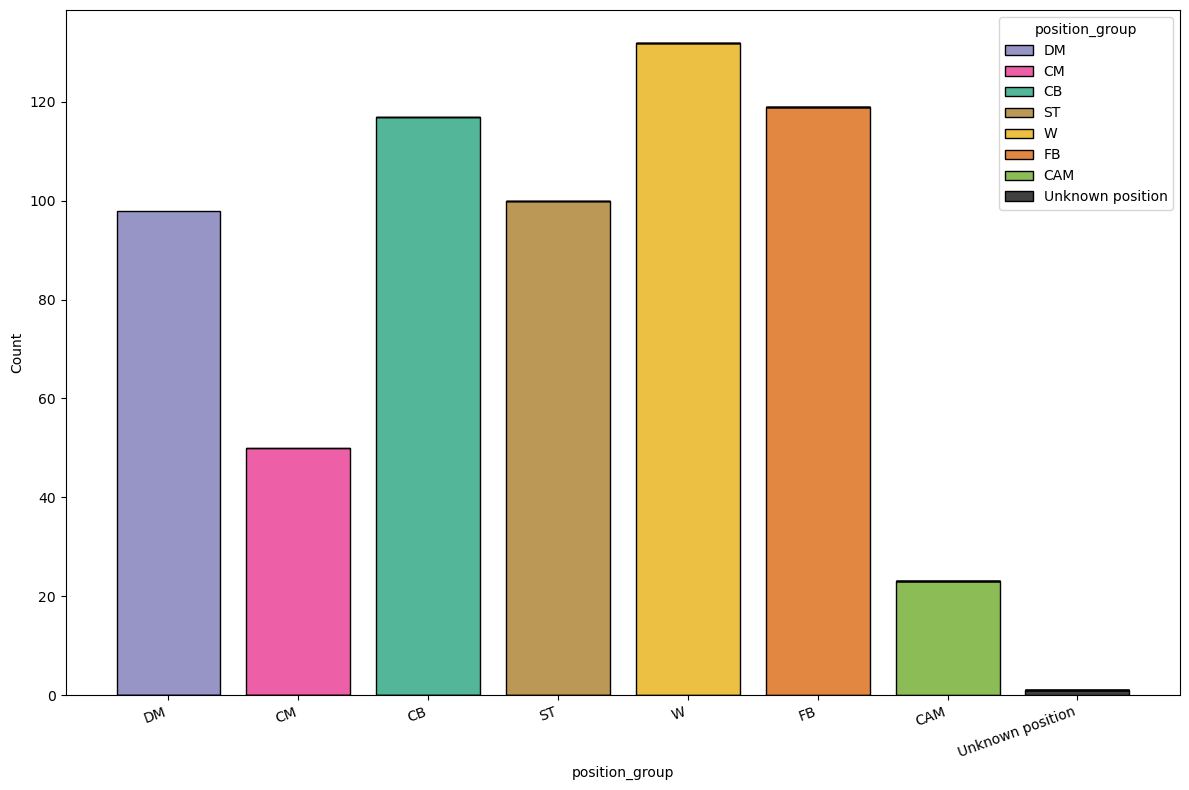

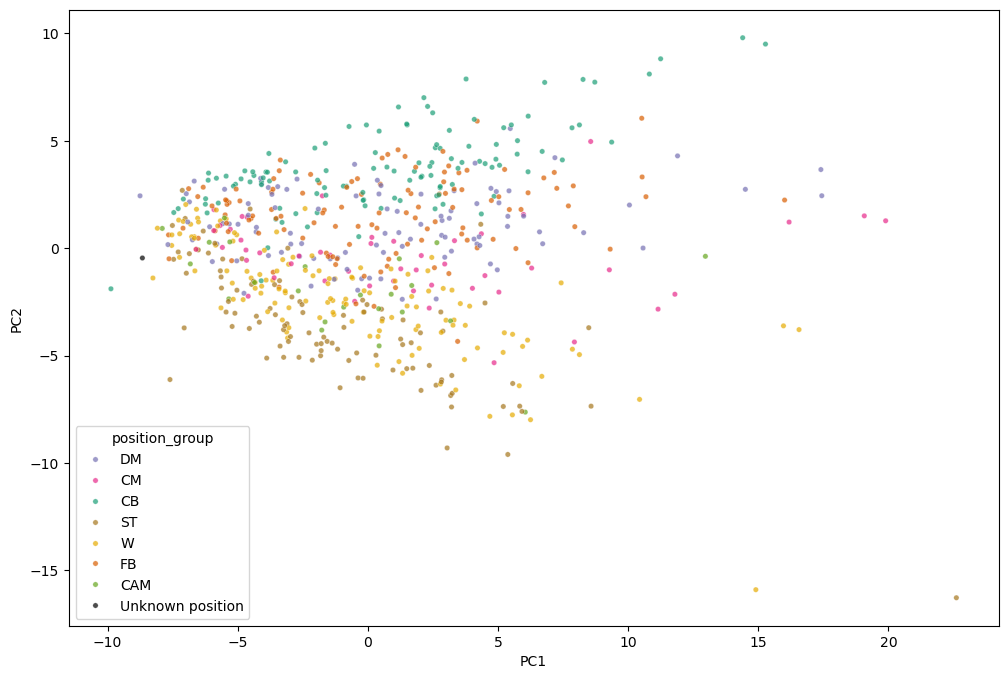

In [23]:

# Plot counts for positional groups
plot_position_colours = {
    **position_colours,
    "Unknown position": "black",
}
fig, ax = plt.subplots(figsize=(12, 8))
sns.histplot(
    data=player_pca_df,
    x="position_group",
    hue="position_group",
    palette=plot_position_colours,
    multiple="stack",
    shrink=0.8,
    ax=ax
)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
# plt.show()


fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=player_pca_df,
    x="PC1",
    y="PC2",
    hue="position_group",
    palette=plot_position_colours,
    alpha=0.7,
    s=15,
    ax=ax
)
plt.show()

#### Principle components vs Goals and Shots


In [60]:
# print all numeric columns in player_feature_matrix
numeric_cols = player_feature_matrix.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

['Unnamed: 0_mean', 'period_mean', 'possession_mean', 'duration_mean', 'type.id_mean', 'possession_team.id_mean', 'play_pattern.id_mean', 'team.id_mean', 'tactics.formation_mean', 'player.id_mean', 'position.id_mean', 'pass.recipient.id_mean', 'pass.length_mean', 'pass.angle_mean', 'pass.height.id_mean', 'pass.body_part.id_mean', 'pass.type.id_mean', 'pass.outcome.id_mean', 'ball_receipt.outcome.id_mean', 'duel.type.id_mean', 'clearance.body_part.id_mean', 'shot.statsbomb_xg_mean', 'shot.technique.id_mean', 'shot.body_part.id_mean', 'shot.type.id_mean', 'shot.outcome.id_mean', 'goalkeeper.position.id_mean', 'goalkeeper.type.id_mean', 'goalkeeper.technique.id_mean', 'goalkeeper.outcome.id_mean', 'duel.outcome.id_mean', 'dribble.outcome.id_mean', 'foul_committed.card.id_mean', 'pass.technique.id_mean', 'interception.outcome.id_mean', '50_50.outcome.id_mean', 'substitution.outcome.id_mean', 'substitution.replacement.id_mean', 'goalkeeper.body_part.id_mean', 'foul_committed.type.id_mean', 

In [41]:
shot_outcome_counts = (
    events_df.dropna(subset=["player_name", "shot_outcome"])
    .groupby(["player_name", "shot_outcome"])
    .size()
    .unstack(fill_value=0)
    .add_prefix("shots_")
)

# Drop previous results so this cell can be rerun safely.
player_feature_matrix = player_feature_matrix.drop(
    columns=shot_outcome_counts.columns,
    errors="ignore",
)
player_feature_matrix = player_feature_matrix.join(
    shot_outcome_counts,
    how="left",
).fillna(0)

shot_events = events_df[
    events_df["event_type"].eq("Shot")
    & events_df["player_name"].notna()
]

total_shots = (
    shot_events.groupby("player_name")
    .size()
    .rename("total_shots")
)

player_feature_matrix = player_feature_matrix.drop(
    columns=["total_shots"],
    errors="ignore",
).join(
    total_shots,
    how="left",
).fillna(0)

player_feature_matrix["total_shots"] = (
    player_feature_matrix["total_shots"].astype(int)
)

Correlation between PC1 and Goals scored: 0.57
Correlation between PC1 and total_shots scored: -0.64


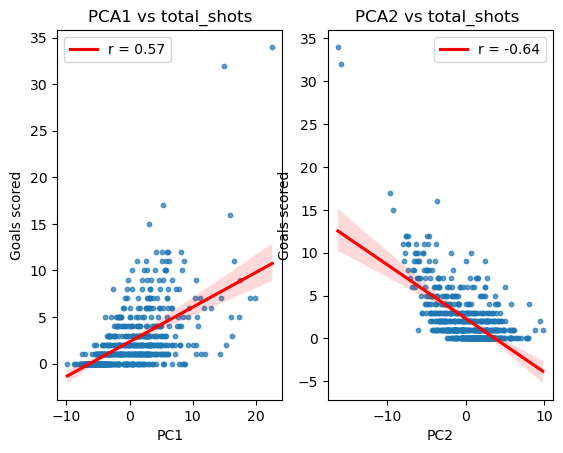

In [42]:


# Compute the correlation between PC1 and Goals scored
correlation_goals1 = player_pca_df["PC1"].corr(player_feature_matrix["total_shots"])
print(f"Correlation between PC1 and Goals scored: {correlation_goals1:.2f}")

# Plot PCA1 vs Goals scored for each player 
fig, (ax, ax2) = plt.subplots(1,2)
ax.scatter(
    player_pca_df["PC1"],
    player_feature_matrix["total_shots"],
    alpha=0.7,
    s=10
)
# Plot a linear regression line
sns.regplot(
    ax=ax,
    x=player_pca_df["PC1"],
    y=player_feature_matrix["total_shots"],
    scatter=False,
    color="red",
    line_kws={"label": f"y={correlation_goals1:.2f}x + b"},
    label=f"r = {correlation_goals1:.2f}"
)

# Compute the correlation between PC1 and Goals scored
correlation_goals2 = player_pca_df["PC2"].corr(player_feature_matrix["total_shots"])
print(f"Correlation between PC1 and total_shots scored: {correlation_goals2:.2f}")
ax2.scatter(
    player_pca_df["PC2"],
    player_feature_matrix["total_shots"],
    alpha=0.7,
    s=10
)
# Plot a linear regression line
sns.regplot(
    ax=ax2,
    x=player_pca_df["PC2"],
    y=player_feature_matrix["total_shots"],
    scatter=False,
    color="red",
    line_kws={"label": f"y={correlation_goals2:.2f}x + b"},
    label=f"r = {correlation_goals2:.2f}"
)
ax.legend()
ax.set_ylabel("PC1")
ax.set_ylabel("Goals scored")
ax.set_title("PCA1 vs total_shots")
ax2.legend()
ax2.set_ylabel("PC2")
ax2.set_ylabel("Goals scored")
ax2.set_title("PCA2 vs total_shots ")
plt.show()



Correlation between PC1 and Goals scored: 0.36
Correlation between PC1 and Goals scored: -0.52


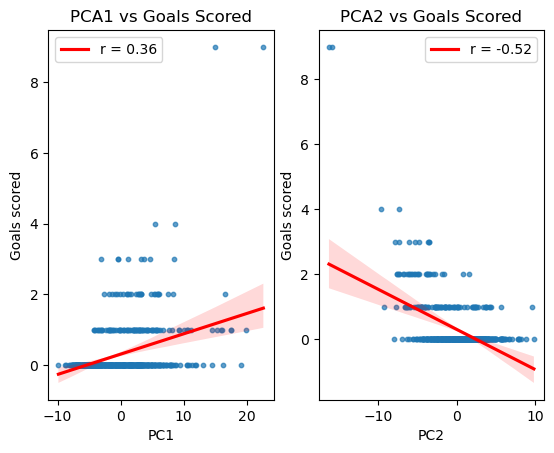

In [43]:
# Compute the correlation between PC1 and Goals scored
correlation_goals1 = player_pca_df["PC1"].corr(player_feature_matrix["shots_Goal"])
print(f"Correlation between PC1 and Goals scored: {correlation_goals1:.2f}")

# Plot PCA1 vs Goals scored for each player 
fig, (ax, ax2) = plt.subplots(1,2)
ax.scatter(
    player_pca_df["PC1"],
    player_feature_matrix["shots_Goal"],
    alpha=0.7,
    s=10
)
# Plot a linear regression line
sns.regplot(
    ax=ax,
    x=player_pca_df["PC1"],
    y=player_feature_matrix["shots_Goal"],
    scatter=False,
    color="red",
    line_kws={"label": f"y={correlation_goals1:.2f}x + b"},
    label=f"r = {correlation_goals1:.2f}"
)

# Compute the correlation between PC1 and Goals scored
correlation_goals2 = player_pca_df["PC2"].corr(player_feature_matrix["shots_Goal"])
print(f"Correlation between PC1 and Goals scored: {correlation_goals2:.2f}")
ax2.scatter(
    player_pca_df["PC2"],
    player_feature_matrix["shots_Goal"],
    alpha=0.7,
    s=10
)
# Plot a linear regression line
sns.regplot(
    ax=ax2,
    x=player_pca_df["PC2"],
    y=player_feature_matrix["shots_Goal"],
    scatter=False,
    color="red",
    line_kws={"label": f"y={correlation_goals2:.2f}x + b"},
    label=f"r = {correlation_goals2:.2f}"
)
ax.legend()
ax.set_ylabel("PC1")
ax.set_ylabel("Goals scored")
ax.set_title("PCA1 vs Goals Scored")
ax2.legend()
ax2.set_ylabel("PC2")
ax2.set_ylabel("Goals scored")
ax2.set_title("PCA2 vs Goals Scored")
plt.show()



In [44]:
# Sort players by the number of goals they scored in the competition
print(player_pca_df.columns.to_list())
# player_feature_matrix = player_feature_matrix.sort_values(by="Goal", ascending=False)
# print(player_feature_matrix[["player_name", "Goal"]].head(10))

['PC1', 'PC2', 'team_name', 'position', 'position_group']
